# 🫁 CXR DenseNet121 — Clasificación Multietiqueta (v5 · CPU · listo para *stacking*)
## TFM · Sistema de Apoyo a la Decisión Clínica Multimodal · Módulo de Imagen
### Universidad de Salamanca · Máster en Análisis Avanzado de Datos Multivariantes y Big Data

---

## 🎯 Qué es este notebook y en qué se diferencia de v3/v4

Este es el módulo de **imagen** (radiografía de tórax) del sistema multimodal. Su salida
final son las **probabilidades calibradas de las 6 etiquetas**, pensadas para alimentar el
**meta-modelo de fusión tardía (stacking)** junto con las ramas tabular (XGBoost) y ECG (ResNet1D).

La v3 y la v4 se quedaban en AUC ≈ 0.50–0.56 (cerca del azar). El diagnóstico —tras revisar
los `.npy`, los CSV y la documentación— identificó **tres causas reales** que esta v5 corrige:

| # | Problema en v3/v4 | Corrección en v5 |
|---|---|---|
| **A** | El backbone CheXpert (`resnet50-res512-all`) recibía imágenes en rango **z-score ImageNet** (~[−2.1, 2.6]), 3→1 canal por `mean()`, a **160×160**. Eso es un dominio de entrada que el backbone nunca vio → embeddings casi-ruido. | Preprocesado **alineado con torchxrayvision**: 1 canal, **min-max por imagen → rango [−1024, 1024]** (lo que el modelo espera), a **224×224**. |
| **B** | Backbone `ResNet50@512` enorme y lento; inviable en CPU. | **DenseNet121 (`densenet121-res224-all`)**: ~8M params, **nativo 224**, y entrenado justo en las patologías torácicas de MIMIC/CheXpert. Estándar de facto (CheXNet). |
| **C** | Atelectasis (118 neg) y Lung Opacity (175 neg) **casi sin negativos** → imposibles de discriminar. *No Finding* sin negativos → no entrenable. | **Negativos derivados por exclusividad clínica** (ver abajo). |

## 🔑 La idea central: negativos derivados por exclusividad mutua

Las etiquetas son clínicamente excluyentes con *No Finding*:

- Si `No Finding == 1` → el paciente **no tiene** ninguna patología → las 5 patologías = **0**.
- Si **alguna** patología `== 1` → entonces `No Finding = **0**`.

Esto **solo rellena posiciones que estaban como NaN** (sin observar) y **nunca pisa** un valor
explícito (0/1) ni un incierto (-1). Con ello Atelectasis pasa de ~118 a ~1.500 negativos y
*No Finding* gana miles de negativos → ambas se vuelven aprendibles. Es una suposición estándar
en la literatura CXR; se documenta como decisión de modelado y es **configurable** con un flag.

## 🛡️ El masking SIGUE intacto

| Valor original | label | mask | ¿entra en la loss? |
|---|---|---|---|
| `1` | 1 | 1 | sí |
| `0` | 0 | 1 | sí |
| `-1` (incierto) | según `uncertainty_policy` | 1 | sí (igual que v3/v4) |
| `NaN` cubierto por exclusividad | 0 | 1 | **sí (negativo derivado, nuevo)** |
| `NaN` no cubierto | 0 | **0** | **no (sigue enmascarado)** |

## 📊 Métricas honestas

- **macro_AUC_core** = media sobre {Cardiomegaly, Edema, Pleural Effusion} (las de balance razonable).
- **macro_AUC_path** = media sobre las 5 patologías (incluye Atelectasis y Lung Opacity ya rescatadas).
- **No Finding** se reporta **aparte**, nunca dentro del macro.
- Se reportan TODAS las etiquetas por separado + nº de positivos/negativos efectivos.

## 🧱 Salidas para el *stacking* (lo que de verdad consume el meta-modelo)

- `cxr_oof_train.csv` → probabilidades **out-of-fold** del train (sin fuga: cada muestra la predice
  un modelo que no la vio) → *features* para entrenar el meta-modelo.
- `cxr_pred_val.csv` y `cxr_pred_test.csv` → probabilidades (crudas y **calibradas** con isotónica).

## ⏱️ Coste en tu PC (i5-1135G7, 4 núcleos, **sin GPU** → CPU)

- Único paso lento: **calcular los embeddings una vez** (backbone congelado) → ~30–45 min.
  Se **cachean en disco**, así que re-ejecutar es instantáneo.
- Búsqueda de hiperparámetros (Optuna sobre embeddings) + K-fold + calibración → **minutos**.
- **Total ≈ 1 hora la primera vez**, segundos las siguientes. Sin fine-tuning end-to-end.


In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ CELDA 1 · INSTALACIÓN DE DEPENDENCIAS                                   ║
# ╚══════════════════════════════════════════════════════════════════════════╝
# torchxrayvision  -> backbone DenseNet121 preentrenado en radiografías
# optuna           -> búsqueda de hiperparámetros (TPE) sobre embeddings cacheados
# scikit-learn     -> métricas (AUC, AP, F1) + IsotonicRegression (calibración)
import subprocess, sys

packages = [
    "torchxrayvision", "optuna", "scikit-learn",
    "pandas", "numpy", "matplotlib", "seaborn", "tqdm"
]

for pkg in packages:
    result = subprocess.run(
        [sys.executable, "-m", "pip", "install", pkg, "-q", "--no-cache-dir"],
        capture_output=True, text=True
    )
    if result.returncode == 0:
        print(f"✅ {pkg}")
    else:
        print(f"⚠️  {pkg} — warning (puede estar ya instalado):")
        print(result.stderr[-300:])

# Verificar imports críticos
import importlib
critical = {"torchxrayvision": "torchxrayvision", "optuna": "optuna",
            "sklearn": "scikit-learn", "torch": "torch"}
print("\n── Verificación de imports ──")
for mod, pkg in critical.items():
    try:
        m = importlib.import_module(mod)
        ver = getattr(m, "__version__", "?")
        print(f"  ✅ {pkg} {ver}")
    except ImportError:
        print(f"  ❌ {pkg} — NO encontrado, instalar manualmente")

print("\nDependencias listas.")

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ CELDA 2 · IMPORTS, SEMILLAS, HILOS DE CPU Y DISPOSITIVO                     ║
# ╚══════════════════════════════════════════════════════════════════════════╝
import os, gc, json, time, copy, random, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset, WeightedRandomSampler

import torchxrayvision as xrv

from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score
from sklearn.isotonic import IsotonicRegression

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)  # menos ruido en el log

warnings.filterwarnings("ignore")

# --- Reproducibilidad ---------------------------------------------------------
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# --- Hilos de CPU: tu i5-1135G7 tiene 4 núcleos físicos -----------------------
N_CORES = 4
torch.set_num_threads(N_CORES)
os.environ["OMP_NUM_THREADS"] = str(N_CORES)
os.environ["MKL_NUM_THREADS"] = str(N_CORES)

# --- Dispositivo: no hay GPU NVIDIA en este equipo -> CPU ---------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"PyTorch        : {torch.__version__}")
print(f"torchxrayvision: {xrv.__version__}")
print(f"Dispositivo    : {DEVICE}  (CPU esperado en este equipo)")
print(f"Hilos CPU      : {torch.get_num_threads()}")


In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ CELDA 3 · RUTAS, ETIQUETAS Y CONSTANTES GLOBALES                           ║
# ╚══════════════════════════════════════════════════════════════════════════╝
# NOTA de diseño:
#  - Forzamos cxr_<split>.npy (320x320). NO usamos cxr_train_224.npy porque está
#    corrupto (pickled, no carga con mmap). Esto sustituye al [FIX 24] de v4.
#  - test_clean.csv tiene 464 filas (el .npy tiene 4640): es INTENCIONAL. El estudio
#    Symile original es de retrieval (1 positivo + 9 distractores), por eso el test
#    etiquetado "limpio" es un subconjunto. El join se queda con esas 464. Correcto.

BASE = Path(r"C:\TFM\1.Opción - Symile Mimic\symile-mimic-a-multimodal-clinical-dataset-of-chest-x-rays-electrocardiograms-and-blood-labs-from-mimic-iv-1.0.0")

CSV_DIR   = BASE / "data_csv" / "clean"
TRAIN_CSV = CSV_DIR / "train_clean.csv"
VAL_CSV   = CSV_DIR / "val_clean.csv"
TEST_CSV  = CSV_DIR / "test_clean.csv"

NPY_DIR        = BASE / "data_npy"
CXR_TRAIN_NPY  = NPY_DIR / "train" / "cxr_train.npy"
CXR_VAL_NPY    = NPY_DIR / "val"   / "cxr_val.npy"
CXR_TEST_NPY   = NPY_DIR / "test"  / "cxr_test.npy"
HADM_TRAIN_NPY = NPY_DIR / "train" / "hadm_id_train.npy"
HADM_VAL_NPY   = NPY_DIR / "val"   / "hadm_id_val.npy"
HADM_TEST_NPY  = NPY_DIR / "test"  / "hadm_id_test.npy"

OUTPUT_DIR = Path("outputs_cxr_densenet121_v5")
OUTPUT_DIR.mkdir(exist_ok=True)
EMB_DIR = OUTPUT_DIR / "embeddings"
EMB_DIR.mkdir(exist_ok=True)

# --- Etiquetas ----------------------------------------------------------------
LABELS = ["Atelectasis", "Cardiomegaly", "Edema", "Lung Opacity", "No Finding", "Pleural Effusion"]
N_LABELS = len(LABELS)
NO_FINDING = "No Finding"
PATHOLOGY_LABELS = [l for l in LABELS if l != NO_FINDING]            # 5 patologías
CORE_LABELS      = ["Cardiomegaly", "Edema", "Pleural Effusion"]      # balance razonable

# --- Preprocesado de imagen ---------------------------------------------------
IMG_SIZE = 224           # nativo de densenet121-res224-all
XRV_RANGE = 1024.0       # torchxrayvision espera entrada en [-1024, 1024]
BACKBONE_WEIGHTS = "densenet121-res224-all"

# --- Regla de negativos derivados (la idea central de la v5) ------------------
# Si No Finding==1 -> patologías=0 ; si alguna patología==1 -> No Finding=0.
# Solo rellena NaN; nunca pisa valores explícitos. Ponlo en False para comparar.
DERIVE_NEGATIVES_FROM_EXCLUSIVITY = True

# --- Metadatos clínicos (rama auxiliar de la cabeza) --------------------------
GENDER_MAP    = {0: 0, 1: 1, "0": 0, "1": 1, "M": 1, "F": 0}
RACE_MAP      = {"UNKNOWN": 0, "WHITE": 1, "BLACK": 2, "ASIAN": 3, "HISPANIC_LATINO": 4, "OTHER_KNOWN": 0}
ADMISSION_MAP = {"SCHEDULED": 0, "EMERGENCY": 1, "OBSERVATION": 2, "URGENT": 3}
ADM_LOC_MAP   = {"EMERGENCY_ROOM": 0, "REFERRAL": 1, "TRANSFER": 2, "INTRA_HOSPITAL": 3}
CXR_VIEW_MAP  = {"AP": 0, "PA": 1}
RACE_ONEHOT   = 5   # indices 0..4 (OTHER_KNOWN se agrupa en UNKNOWN)
# META = edad + sexo + raza(5) + tipo_ingreso(4) + lugar_ingreso(4) + horas_ingreso_a_cxr(1) + vista(2)
META_DIM = 1 + 1 + RACE_ONEHOT + len(ADMISSION_MAP) + len(ADM_LOC_MAP) + 1 + len(CXR_VIEW_MAP)  # = 18

# --- Presupuesto de cómputo (ajustable) ---------------------------------------
OPTUNA_TRIALS   = 25     # búsqueda de hiperparámetros (barata sobre embeddings)
K_FOLDS         = 5      # K-fold final -> estimación honesta + OOF para stacking
TUNE_EPOCHS     = 20     # epochs por entrenamiento durante la búsqueda
TUNE_PATIENCE   = 5
FINAL_EPOCHS    = 40     # epochs del K-fold final
FINAL_PATIENCE  = 8
HEAD_BATCH      = 128    # batch para la cabeza (embeddings -> rápido y BN estable)
EMB_BATCH       = 16     # batch para la pasada del backbone (imágenes)

print("Constantes configuradas.")
print(f"  Backbone           : {BACKBONE_WEIGHTS}  @ {IMG_SIZE}x{IMG_SIZE}")
print(f"  Negativos derivados: {DERIVE_NEGATIVES_FROM_EXCLUSIVITY}")
print(f"  META_DIM           : {META_DIM}")
print(f"  Macro 'core'       : {CORE_LABELS}")
print(f"  Macro 'patologías' : {PATHOLOGY_LABELS}")


In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ CELDA 4 · CARGA Y ALINEACIÓN CSV <-> NPY (join por hadm_id)                 ║
# ╚══════════════════════════════════════════════════════════════════════════╝
# Cada fila del CSV limpio se enlaza con su imagen en el .npy mediante hadm_id.
# El .npy de imágenes se abre con mmap_mode='r' (mapeado en disco, no a RAM).

def load_split(csv_path, cxr_npy_path, hadm_npy_path, name):
    print(f"\n-- Split '{name}' " + "-" * 40)
    df = pd.read_csv(csv_path, sep=";")
    print(f"   CSV filas         : {len(df):,}")

    hadm = np.load(hadm_npy_path, allow_pickle=True)              # hadm_id por índice del npy
    hadm_to_idx = {int(h): i for i, h in enumerate(hadm)}
    print(f"   npy hadm_id count : {len(hadm):,}")

    df["_npy_idx"] = df["hadm_id"].map(lambda h: hadm_to_idx.get(int(h), -1))
    n0 = len(df)
    df = df[df["_npy_idx"] >= 0].reset_index(drop=True)           # descarta sin imagen
    print(f"   Filas con imagen  : {len(df):,}  (descartadas: {n0 - len(df)})")

    cxr = np.load(cxr_npy_path, mmap_mode="r")
    print(f"   CXR npy           : shape={cxr.shape} dtype={cxr.dtype}")
    return df, cxr

df_train, cxr_train = load_split(TRAIN_CSV, CXR_TRAIN_NPY, HADM_TRAIN_NPY, "train")
df_val,   cxr_val   = load_split(VAL_CSV,   CXR_VAL_NPY,   HADM_VAL_NPY,   "val")
df_test,  cxr_test  = load_split(TEST_CSV,  CXR_TEST_NPY,  HADM_TEST_NPY,  "test")

print(f"\nResumen: train={len(df_train):,}  val={len(df_val):,}  test={len(df_test):,}")


In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ CELDA 5 · CONSTRUCCIÓN DE OBJETIVOS: MASKING + NEGATIVOS DERIVADOS          ║
# ╚══════════════════════════════════════════════════════════════════════════╝
# build_targets() convierte el DataFrame en dos matrices (N x 6):
#   labels[i,j] -> etiqueta 0/1 que el modelo debe predecir
#   mask[i,j]   -> 1 si esa etiqueta entra en la pérdida, 0 si se enmascara
#
# Reglas (en este orden de prioridad):
#   1 -> label=1, mask=1
#   0 -> label=0, mask=1
#  -1 -> label = (1 si policy=='ones' else 0), mask=1     (manejo de inciertos, sin cambios)
# NaN -> por defecto label=0, mask=0  (ENMASCARADO)
#        EXCEPTO si la exclusividad clínica nos da certeza:
#           - No Finding==1  => patología NaN pasa a 0 observado (mask=1)
#           - alguna patología==1 => No Finding NaN pasa a 0 observado (mask=1)
#        La derivación NUNCA sobreescribe un valor explícito o incierto.

def build_targets(df, uncertainty_policy="zeros", derive=DERIVE_NEGATIVES_FROM_EXCLUSIVITY,
                  verbose=False):
    raw = df[LABELS].to_numpy(dtype=float)            # contiene NaN, -1, 0, 1
    N = raw.shape[0]
    labels = np.zeros((N, N_LABELS), dtype=np.float32)
    mask   = np.zeros((N, N_LABELS), dtype=np.float32)

    observed = ~np.isnan(raw)                          # 1/0/-1 observados
    mask[observed] = 1.0                               # de momento todo lo observado entra
    labels[raw == 1] = 1.0
    unc = (raw == -1)
    labels[unc] = 1.0 if uncertainty_policy == "ones" else 0.0   # política de inciertos

    nf = LABELS.index(NO_FINDING)
    path_cols = [j for j in range(N_LABELS) if j != nf]
    n_contra = 0
    n_der_path = 0
    n_der_nf = 0

    if derive:
        # (a) No Finding==1  ->  patologías ausentes (0) donde estaban SIN observar
        nf_pos_rows = (raw[:, nf] == 1)
        for j in path_cols:
            fill = nf_pos_rows & np.isnan(raw[:, j])   # solo NaN; respeta lo explícito
            labels[fill, j] = 0.0
            mask[fill, j]   = 1.0
            n_der_path += int(fill.sum())
        # contradicciones (No Finding==1 y patología==1 a la vez): se respeta el explícito
        n_contra = int((nf_pos_rows[:, None] & (raw[:, path_cols] == 1)).sum())

        # (b) alguna patología==1  ->  No Finding=0 donde estaba SIN observar
        any_path_pos = (raw[:, path_cols] == 1).any(axis=1)
        fill_nf = any_path_pos & np.isnan(raw[:, nf])
        labels[fill_nf, nf] = 0.0
        mask[fill_nf, nf]   = 1.0
        n_der_nf = int(fill_nf.sum())

    if verbose:
        print(f"   Negativos derivados en patologías : {n_der_path:,}")
        print(f"   Negativos derivados en No Finding : {n_der_nf:,}")
        print(f"   Contradicciones detectadas (resp.): {n_contra:,}")
    return labels, mask


def describe_balance(df, name):
    print(f"\n== Balance efectivo '{name}' (policy=zeros, derive={DERIVE_NEGATIVES_FROM_EXCLUSIVITY}) ==")
    y, m = build_targets(df, "zeros", verbose=(name == "train"))
    print(f"   {'Etiqueta':18s} {'pos':>6} {'neg':>6} {'enmascarados':>13} {'pos_weight≈':>11}")
    for j, lbl in enumerate(LABELS):
        sel = m[:, j] == 1
        pos = int((y[sel, j] == 1).sum()); neg = int((y[sel, j] == 0).sum())
        masked = int((m[:, j] == 0).sum())
        pw = neg / max(pos, 1)
        print(f"   {lbl:18s} {pos:6d} {neg:6d} {masked:13d} {pw:11.3f}")

describe_balance(df_train, "train")


In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ CELDA 6 · METADATOS CLÍNICOS (rama auxiliar)                               ║
# ╚══════════════════════════════════════════════════════════════════════════╝
# Vector de 13 dimensiones por muestra: edad (normalizada), género, y one-hot de
# raza / tipo de ingreso / vista radiológica. Sirve a la cabeza para condicionar
# la predicción (p.ej. la vista PA/AP afecta a la apariencia de la radiografía).

AGE_MIN, AGE_MAX = float(df_train["age"].min()), float(df_train["age"].max())
HRS_MIN, HRS_MAX = float(df_train["hours_adm_to_cxr"].min()), float(df_train["hours_adm_to_cxr"].max())

def build_metadata(df):
    # Vector de 18 dims: edad, sexo, raza(5), tipo de ingreso(4), lugar de ingreso(4),
    # horas del ingreso a la radiografia (1) y vista AP/PA(2). 'admission_location' y
    # 'hours_adm_to_cxr' se anaden como contexto clinico (proxy de gravedad/curso).
    N = len(df)
    M = np.zeros((N, META_DIM), dtype=np.float32)
    for i, (_, row) in enumerate(df.iterrows()):
        off = 0
        M[i, off] = (float(row.get("age", AGE_MIN)) - AGE_MIN) / (AGE_MAX - AGE_MIN + 1e-8); off += 1
        M[i, off] = float(GENDER_MAP.get(row.get("gender", 0), 0)); off += 1
        M[i, off + RACE_MAP.get(str(row.get("race", "UNKNOWN")).upper(), 0)] = 1.0; off += RACE_ONEHOT
        M[i, off + ADMISSION_MAP.get(str(row.get("admission_type", "EMERGENCY")).upper(), 1)] = 1.0; off += len(ADMISSION_MAP)
        M[i, off + ADM_LOC_MAP.get(str(row.get("admission_location", "EMERGENCY_ROOM")).upper(), 0)] = 1.0; off += len(ADM_LOC_MAP)
        M[i, off] = (float(row.get("hours_adm_to_cxr", HRS_MIN)) - HRS_MIN) / (HRS_MAX - HRS_MIN + 1e-8); off += 1
        M[i, off + CXR_VIEW_MAP.get(str(row.get("cxr_view", "AP")).upper(), 0)] = 1.0; off += len(CXR_VIEW_MAP)
    return M

meta_train = build_metadata(df_train)
meta_val   = build_metadata(df_val)
meta_test  = build_metadata(df_test)
print(f"Metadatos: train={meta_train.shape} val={meta_val.shape} test={meta_test.shape}")


In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ CELDA 7 · PREPROCESADO DE IMAGEN ALINEADO CON TORCHXRAYVISION (corrección A)║
# ╚══════════════════════════════════════════════════════════════════════════╝
# Los .npy vienen normalizados z-score (estilo ImageNet, ~[-2.1, 2.6], 3 canales).
# torchxrayvision espera: 1 canal, rango [-1024, 1024], 224x224.
#
# Como el z-score es una transformación AFÍN, un min-max por imagen recupera la
# estructura [0,1] original sin necesidad de conocer la media/desv exactas usadas.
# Después escalamos a [-1024, 1024], que es exactamente lo que el backbone espera.

class CXRImageDataset(Dataset):
    # Devuelve tensores (1, 224, 224) listos para el backbone xrv.
    def __init__(self, df, cxr_npy):
        self.idx = df["_npy_idx"].to_numpy()
        self.cxr = cxr_npy

    def __len__(self):
        return len(self.idx)

    def __getitem__(self, i):
        arr = np.asarray(self.cxr[int(self.idx[i])], dtype=np.float32)  # (3,320,320)
        g = arr[0] if arr.ndim == 3 else arr                            # 1 canal (gris replicado)
        gmin, gmax = float(g.min()), float(g.max())
        g = (g - gmin) / (gmax - gmin + 1e-8)                           # min-max -> [0,1]
        g = (2.0 * g - 1.0) * XRV_RANGE                                 # -> [-1024, 1024]
        t = torch.from_numpy(g)[None, None]                            # (1,1,H,W)
        t = F.interpolate(t, size=(IMG_SIZE, IMG_SIZE), mode="bilinear", align_corners=False)
        return t[0]                                                     # (1,224,224)

# Comprobación rápida del rango resultante (debe quedar cerca de [-1024, 1024]):
_sample = CXRImageDataset(df_train, cxr_train)[0]
print(f"Muestra preprocesada: shape={tuple(_sample.shape)} "
      f"min={_sample.min():.1f} max={_sample.max():.1f} (esperado ~[-1024, 1024])")


In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ CELDA 8 · BACKBONE DenseNet121 + EXTRACCIÓN DE EMBEDDINGS (corrección B)    ║
# ╚══════════════════════════════════════════════════════════════════════════╝
# Cargamos DenseNet121 preentrenado en TODAS las patologías de CheXpert/MIMIC.
# Lo usamos CONGELADO: solo extraemos el embedding de 1024 dims (avg-pool tras
# el último bloque denso), igual que hace su forward antes del clasificador.

def load_backbone():
    model = xrv.models.DenseNet(weights=BACKBONE_WEIGHTS)
    model.eval()
    for p in model.parameters():
        p.requires_grad = False
    return model.to(DEVICE)

@torch.no_grad()
def extract_embeddings(model, df, cxr_npy, desc):
    loader = DataLoader(CXRImageDataset(df, cxr_npy), batch_size=EMB_BATCH,
                        shuffle=False, num_workers=0)
    out = []
    for x in tqdm(loader, desc=desc, leave=False):
        x = x.to(DEVICE)
        f = model.features(x)                       # (N,1024,7,7)
        f = F.relu(f, inplace=True)
        f = F.adaptive_avg_pool2d(f, (1, 1)).reshape(f.shape[0], -1)  # (N,1024)
        out.append(f.cpu().numpy())
    return np.concatenate(out, axis=0).astype(np.float32)

print("Backbone:", BACKBONE_WEIGHTS, "(se descargará la 1a vez)")


In [11]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ CELDA 9 · CALCULAR (O CARGAR) EMBEDDINGS — único paso lento (~30-45 min)    ║
# ╚══════════════════════════════════════════════════════════════════════════╝
# Se cachean en disco. Si ya existen, se cargan en segundos (re-ejecución barata).

EMB_TRAIN_PATH = EMB_DIR / "emb_train.npy"
EMB_VAL_PATH   = EMB_DIR / "emb_val.npy"
EMB_TEST_PATH  = EMB_DIR / "emb_test.npy"

if EMB_TRAIN_PATH.exists() and EMB_VAL_PATH.exists() and EMB_TEST_PATH.exists():
    emb_train = np.load(EMB_TRAIN_PATH)
    emb_val   = np.load(EMB_VAL_PATH)
    emb_test  = np.load(EMB_TEST_PATH)
    print("Embeddings cargados desde caché.")
else:
    t0 = time.time()
    backbone = load_backbone()
    emb_train = extract_embeddings(backbone, df_train, cxr_train, "train")
    np.save(EMB_TRAIN_PATH, emb_train)
    emb_val = extract_embeddings(backbone, df_val, cxr_val, "val")
    np.save(EMB_VAL_PATH, emb_val)
    emb_test = extract_embeddings(backbone, df_test, cxr_test, "test")
    np.save(EMB_TEST_PATH, emb_test)
    del backbone; gc.collect()
    print(f"Embeddings calculados y cacheados en {(time.time()-t0)/60:.1f} min.")

EMB_DIM = emb_train.shape[1]
print(f"emb_train={emb_train.shape}  emb_val={emb_val.shape}  emb_test={emb_test.shape}  EMB_DIM={EMB_DIM}")


Embeddings calculados y cacheados en 24.0 min.
emb_train=(10000, 1024)  emb_val=(750, 1024)  emb_test=(464, 1024)  EMB_DIM=1024


In [12]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ CELDA 10 · CABEZA DE CLASIFICACIÓN + PÉRDIDA ENMASCARADA + UTILIDADES       ║
# ╚══════════════════════════════════════════════════════════════════════════╝

class LabelCorrelation(nn.Module):
    # Mezcla suave entre logits para modelar co-ocurrencia (Jaccard<=0.30 -> aporte modesto).
    def __init__(self, n=N_LABELS):
        super().__init__()
        self.lin = nn.Linear(n, n, bias=False)
        nn.init.eye_(self.lin.weight); self.lin.weight.data *= 0.1
        self.norm = nn.LayerNorm(n)
    def forward(self, x):
        return self.norm(x + self.lin(x))


class CXRHead(nn.Module):
    # Embedding (1024) + metadatos (13) -> fusión -> logits (6).
    def __init__(self, emb_dim=EMB_DIM, dropout=0.3, use_corr=True, use_meta=True):
        super().__init__()
        self.use_meta = use_meta
        self.img = nn.Sequential(nn.Linear(emb_dim, 512), nn.BatchNorm1d(512), nn.ReLU(inplace=True))
        if use_meta:
            self.meta = nn.Sequential(nn.Linear(META_DIM, 64), nn.BatchNorm1d(64), nn.ReLU(inplace=True))
            fused = 512 + 64
        else:
            self.meta = None; fused = 512
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(fused, 256), nn.BatchNorm1d(256), nn.ReLU(inplace=True),
            nn.Dropout(dropout * 0.5),
            nn.Linear(256, N_LABELS),
        )
        self.corr = LabelCorrelation() if use_corr else None
        for m in self.head.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, emb, meta=None):
        z = self.img(emb)
        if self.use_meta and meta is not None:
            z = torch.cat([z, self.meta(meta)], dim=1)
        logits = self.head(z)
        if self.corr is not None:
            logits = self.corr(logits)
        return logits


class MaskedLoss(nn.Module):
    # BCE (o focal) con pos_weight por etiqueta y máscara de observabilidad.
    def __init__(self, pos_weight, loss_type="bce", focal_gamma=2.0):
        super().__init__()
        self.register_buffer("pos_weight", pos_weight)
        self.loss_type = loss_type
        self.gamma = focal_gamma
    def forward(self, logits, labels, mask):
        pw = self.pos_weight.to(logits.device)
        if self.loss_type == "focal":
            # focal: baja el peso de los ejemplos fáciles (útil en desequilibrio).
            bce = F.binary_cross_entropy_with_logits(logits, labels, pos_weight=pw, reduction="none")
            p = torch.sigmoid(logits)
            pt = labels * p + (1 - labels) * (1 - p)
            loss = ((1 - pt) ** self.gamma) * bce
        else:
            loss = F.binary_cross_entropy_with_logits(logits, labels, pos_weight=pw, reduction="none")
        loss = loss * mask
        return loss.sum() / mask.sum().clamp(min=1e-8)


def dynamic_pos_weights(y, m, clip=10.0):
    # pos_weight = n_neg / n_pos POR etiqueta, calculado sobre los objetivos EFECTIVOS
    # (ya con política de inciertos + negativos derivados aplicados). Es lo correcto:
    # compensa el desequilibrio que el modelo realmente ve.
    w = np.ones(N_LABELS, dtype=np.float32)
    for j in range(N_LABELS):
        sel = m[:, j] == 1
        pos = (y[sel, j] == 1).sum(); neg = (y[sel, j] == 0).sum()
        w[j] = np.clip(neg / max(pos, 1), 1.0 / clip, clip)
    return torch.tensor(w, dtype=torch.float32)


def sample_weights_by_rarity(y, m):
    # WeightedRandomSampler: da más probabilidad a combinaciones de patologías raras
    # (el EDA: solo 1.2% tiene las 5 a la vez). Mejora el aprendizaje de co-diagnósticos.
    combo = [tuple(int(v) for v in (y[i] * m[i]).astype(int)) for i in range(len(y))]
    from collections import Counter
    c = Counter(combo)
    w = np.array([1.0 / c[k] for k in combo], dtype=np.float64)
    return torch.tensor(w, dtype=torch.double)


def multilabel_metrics(probs, labels, mask, label_list=LABELS, thresholds=None):
    if thresholds is None:
        thresholds = {l: 0.5 for l in label_list}
    res = {}
    for j, lbl in enumerate(LABELS):
        sel = mask[:, j] == 1
        yt = labels[sel, j]; yp = probs[sel, j]
        npos = int(yt.sum()); nneg = int((1 - yt).sum())
        if npos >= 2 and nneg >= 2:
            auc = roc_auc_score(yt, yp); ap = average_precision_score(yt, yp)
        else:
            auc = float("nan"); ap = float("nan")
        thr = thresholds.get(lbl, 0.5)
        f1 = f1_score(yt, (yp >= thr).astype(float), zero_division=0)
        res[lbl] = {"AUC": auc, "AP": ap, "F1": f1, "n_pos": npos, "n_neg": nneg, "thr": thr}
    def macro_auc(group):
        vals = [res[l]["AUC"] for l in group if not np.isnan(res[l]["AUC"])]
        return float(np.mean(vals)) if vals else float("nan")
    res["macro_AUC_core"] = macro_auc(CORE_LABELS)
    res["macro_AUC_path"] = macro_auc(PATHOLOGY_LABELS)
    return res


def best_thresholds_by_f1(probs, labels, mask, label_list=LABELS, grid=None):
    if grid is None:
        grid = np.linspace(0.05, 0.95, 37)
    thr = {}
    for j, lbl in enumerate(LABELS):
        sel = mask[:, j] == 1
        yt = labels[sel, j]; yp = probs[sel, j]
        if yt.sum() < 2:
            thr[lbl] = 0.5; continue
        best_f1, best_t = -1, 0.5
        for t in grid:
            f = f1_score(yt, (yp >= t).astype(float), zero_division=0)
            if f > best_f1: best_f1, best_t = f, t
        thr[lbl] = float(best_t)
    return thr

print("Cabeza, pérdida y utilidades definidas.")


Cabeza, pérdida y utilidades definidas.


In [13]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ CELDA 11 · BUCLE DE ENTRENAMIENTO DE LA CABEZA (sobre embeddings, rápido)   ║
# ╚══════════════════════════════════════════════════════════════════════════╝

def make_loader(emb, meta, y, m, cfg, train=True):
    ds = TensorDataset(torch.tensor(emb), torch.tensor(meta),
                       torch.tensor(y), torch.tensor(m))
    if train and cfg.get("use_sampler", False):
        sw = sample_weights_by_rarity(y, m)
        sampler = WeightedRandomSampler(sw, num_samples=len(sw), replacement=True)
        return DataLoader(ds, batch_size=HEAD_BATCH, sampler=sampler, drop_last=True)
    return DataLoader(ds, batch_size=HEAD_BATCH, shuffle=train, drop_last=train)


def train_head(emb_tr, meta_tr, y_tr, m_tr, emb_va, meta_va, y_va, m_va,
               cfg, n_epochs, patience, verbose=False):
    # pos_weight dinámico calculado SOBRE EL FOLD de entrenamiento actual.
    pw = dynamic_pos_weights(y_tr, m_tr)
    criterion = MaskedLoss(pw, loss_type=cfg.get("loss_type", "bce")).to(DEVICE)

    head = CXRHead(EMB_DIM, dropout=cfg["dropout"],
                   use_corr=cfg["use_corr"], use_meta=cfg["use_meta"]).to(DEVICE)
    opt = torch.optim.AdamW(head.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"])
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs, eta_min=1e-7)

    loader_tr = make_loader(emb_tr, meta_tr, y_tr, m_tr, cfg, train=True)
    best_auc, best_state, waited = -1.0, None, 0

    for ep in range(n_epochs):
        head.train()
        for eb, mb, yb, msb in loader_tr:
            eb, mb, yb, msb = eb.to(DEVICE), mb.to(DEVICE), yb.to(DEVICE), msb.to(DEVICE)
            opt.zero_grad()
            logits = head(eb, mb)
            loss = criterion(logits, yb, msb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(head.parameters(), 1.0)
            opt.step()
        sched.step()

        probs_va = predict_head(head, emb_va, meta_va)
        mva = multilabel_metrics(probs_va, y_va, m_va)
        score = mva["macro_AUC_path"]
        if verbose:
            print(f"    ep{ep+1:02d} macroAUC_path={score:.4f} core={mva['macro_AUC_core']:.4f}")
        if not np.isnan(score) and score > best_auc + 1e-4:
            best_auc, best_state, waited = score, copy.deepcopy(head.state_dict()), 0
        else:
            waited += 1
            if waited >= patience:
                break

    if best_state is not None:
        head.load_state_dict(best_state)
    return head, best_auc


@torch.no_grad()
def predict_head(head, emb, meta):
    head.eval()
    probs = []
    for i in range(0, len(emb), 512):
        eb = torch.tensor(emb[i:i+512]).to(DEVICE)
        mb = torch.tensor(meta[i:i+512]).to(DEVICE)
        probs.append(torch.sigmoid(head(eb, mb)).cpu().numpy())
    return np.concatenate(probs, axis=0)

print("Funciones de entrenamiento/predicción de la cabeza listas.")


Funciones de entrenamiento/predicción de la cabeza listas.


In [14]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ CELDA 12 · BÚSQUEDA DE HIPERPARÁMETROS CON OPTUNA (3-fold CV sobre train)   ║
# ╚══════════════════════════════════════════════════════════════════════════╝
# Como entrenar la cabeza sobre embeddings cuesta segundos, podemos permitirnos
# una búsqueda TPE decente. Objetivo = macro_AUC_path medio en 3-fold CV interno.

def objective(trial):
    cfg = {
        "lr":           trial.suggest_float("lr", 1e-4, 5e-3, log=True),
        "weight_decay": trial.suggest_float("weight_decay", 1e-5, 1e-3, log=True),
        "dropout":      trial.suggest_float("dropout", 0.1, 0.5),
        "use_corr":     trial.suggest_categorical("use_corr", [True, False]),
        "use_meta":     trial.suggest_categorical("use_meta", [True, False]),
        "use_sampler":  trial.suggest_categorical("use_sampler", [True, False]),
        "loss_type":    trial.suggest_categorical("loss_type", ["bce", "focal"]),
        "policy":       trial.suggest_categorical("policy", ["zeros", "ones"]),
    }
    y_all, m_all = build_targets(df_train, cfg["policy"])
    kf = KFold(n_splits=3, shuffle=True, random_state=SEED)
    scores = []
    for tr, va in kf.split(np.arange(len(df_train))):
        head, _ = train_head(
            emb_train[tr], meta_train[tr], y_all[tr], m_all[tr],
            emb_train[va], meta_train[va], y_all[va], m_all[va],
            cfg, TUNE_EPOCHS, TUNE_PATIENCE)
        p = predict_head(head, emb_train[va], meta_train[va])
        scores.append(multilabel_metrics(p, y_all[va], m_all[va])["macro_AUC_path"])
        del head; gc.collect()
    return float(np.nanmean(scores))

t0 = time.time()
study = optuna.create_study(direction="maximize",
                            sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=OPTUNA_TRIALS, show_progress_bar=True)

BEST = study.best_params
print(f"\nBúsqueda terminada en {(time.time()-t0)/60:.1f} min")
print(f"Mejor macro_AUC_path (CV interno): {study.best_value:.4f}")
print("Mejor configuración:")
for k, v in BEST.items():
    print(f"   {k:14s} = {v}")


Best trial: 13. Best value: 0.824014: 100%|██████████| 25/25 [11:28<00:00, 27.55s/it]


Búsqueda terminada en 11.5 min
Mejor macro_AUC_path (CV interno): 0.8240
Mejor configuración:
   lr             = 0.0002253343603960114
   weight_decay   = 7.01047862413305e-05
   dropout        = 0.49032137354537886
   use_corr       = False
   use_meta       = True
   use_sampler    = False
   loss_type      = bce
   policy         = ones


In [15]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ CELDA 13 · K-FOLD FINAL -> OOF para stacking + predicciones test/val        ║
# ╚══════════════════════════════════════════════════════════════════════════╝
# Con la mejor config entrenamos K modelos. Cada muestra de train recibe una
# predicción OOF (de un modelo que NO la vio -> sin fuga, válida para stacking).
# Las predicciones de val y test se promedian sobre los K modelos (ensemble).

cfg = dict(BEST)
y_train, m_train = build_targets(df_train, cfg["policy"])
y_val,   m_val   = build_targets(df_val,   cfg["policy"])
y_test,  m_test  = build_targets(df_test,  cfg["policy"])

oof_train = np.zeros((len(df_train), N_LABELS), dtype=np.float32)
acc_val   = np.zeros((len(df_val),   N_LABELS), dtype=np.float32)
acc_test  = np.zeros((len(df_test),  N_LABELS), dtype=np.float32)

kf = KFold(n_splits=K_FOLDS, shuffle=True, random_state=SEED)
fold_metrics = []
t0 = time.time()
for k, (tr, va) in enumerate(kf.split(np.arange(len(df_train)))):
    head, best_auc = train_head(
        emb_train[tr], meta_train[tr], y_train[tr], m_train[tr],
        emb_train[va], meta_train[va], y_train[va], m_train[va],
        cfg, FINAL_EPOCHS, FINAL_PATIENCE)
    oof_train[va] = predict_head(head, emb_train[va], meta_train[va])
    acc_val  += predict_head(head, emb_val,  meta_val)
    acc_test += predict_head(head, emb_test, meta_test)
    mfold = multilabel_metrics(oof_train[va], y_train[va], m_train[va])
    fold_metrics.append(mfold)
    print(f"Fold {k+1}/{K_FOLDS}: macroAUC_path={mfold['macro_AUC_path']:.4f} core={mfold['macro_AUC_core']:.4f}")
    del head; gc.collect()

val_pred  = acc_val  / K_FOLDS
test_pred = acc_test / K_FOLDS
print(f"\nK-fold terminado en {(time.time()-t0)/60:.1f} min")

# Métricas OOF globales (estimación honesta sobre todo el train)
oof_metrics = multilabel_metrics(oof_train, y_train, m_train)
print(f"OOF macro_AUC_path={oof_metrics['macro_AUC_path']:.4f}  core={oof_metrics['macro_AUC_core']:.4f}")


Fold 1/5: macroAUC_path=0.8280 core=0.8344
Fold 2/5: macroAUC_path=0.8174 core=0.8311
Fold 3/5: macroAUC_path=0.8249 core=0.8387
Fold 4/5: macroAUC_path=0.8270 core=0.8432
Fold 5/5: macroAUC_path=0.8237 core=0.8349

K-fold terminado en 1.3 min
OOF macro_AUC_path=0.8238  core=0.8359


In [16]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ CELDA 14 · CALIBRACIÓN ISOTÓNICA (mejora la calidad de las probabilidades)  ║
# ╚══════════════════════════════════════════════════════════════════════════╝
# La calibración se AJUSTA sobre val (nunca visto en entrenamiento) y se APLICA a
# test y a las OOF. Probabilidades bien calibradas son mejores features de stacking.

calibrators = {}
for j, lbl in enumerate(LABELS):
    sel = m_val[:, j] == 1
    yt = y_val[sel, j]; yp = val_pred[sel, j]
    if len(np.unique(yt)) < 2:
        calibrators[lbl] = None          # sin dos clases -> no se puede calibrar
        continue
    iso = IsotonicRegression(out_of_bounds="clip")
    iso.fit(yp, yt)
    calibrators[lbl] = iso

def apply_calibration(probs):
    out = probs.copy()
    for j, lbl in enumerate(LABELS):
        if calibrators[lbl] is not None:
            out[:, j] = calibrators[lbl].predict(probs[:, j])
    return out

test_pred_cal = apply_calibration(test_pred)
oof_cal       = apply_calibration(oof_train)
print("Calibración isotónica ajustada en val y aplicada a test + OOF.")


Calibración isotónica ajustada en val y aplicada a test + OOF.


In [17]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ CELDA 15 · EVALUACIÓN EN TEST + INFORME POR ETIQUETA                        ║
# ╚══════════════════════════════════════════════════════════════════════════╝
# Umbrales optimizados por F1 sobre val; métricas finales sobre test (calibrado).

thr_val = best_thresholds_by_f1(val_pred, y_val, m_val)
test_metrics = multilabel_metrics(test_pred_cal, y_test, m_test, thresholds=thr_val)

print("MÉTRICAS FINALES EN TEST (probabilidades calibradas)")
print(f"{'Etiqueta':18s} {'AUC':>7} {'AP':>7} {'F1':>7} {'N+':>5} {'N-':>5}   nota")
print("-" * 70)
for lbl in LABELS:
    m = test_metrics[lbl]
    auc = f"{m['AUC']:.4f}" if not np.isnan(m['AUC']) else "  N/A"
    nota = ""
    if lbl == NO_FINDING:                 nota = "(fuera del macro)"
    elif lbl in ("Atelectasis", "Lung Opacity"): nota = "(rescatada por exclusividad)"
    print(f"{lbl:18s} {auc:>7} {m['AP']:7.4f} {m['F1']:7.4f} {m['n_pos']:5d} {m['n_neg']:5d}   {nota}")
print("-" * 70)
print(f"{'MACRO core (3)':18s} {test_metrics['macro_AUC_core']:7.4f}   "
      f"(Cardiomegaly, Edema, Pleural Effusion)")
print(f"{'MACRO patol. (5)':18s} {test_metrics['macro_AUC_path']:7.4f}   "
      f"(las 5 patologías, excluye No Finding)")

# Comparativa de folds (estimación de varianza)
core = [f['macro_AUC_core'] for f in fold_metrics]
path = [f['macro_AUC_path'] for f in fold_metrics]
print(f"\nCV {K_FOLDS}-fold:  core={np.nanmean(core):.4f}±{np.nanstd(core):.4f}   "
      f"path={np.nanmean(path):.4f}±{np.nanstd(path):.4f}")


MÉTRICAS FINALES EN TEST (probabilidades calibradas)
Etiqueta               AUC      AP      F1    N+    N-   nota
----------------------------------------------------------------------
Atelectasis         0.7816  0.8587  0.8459   163    73   (rescatada por exclusividad)
Cardiomegaly        0.7762  0.7993  0.7733   164   111   
Edema               0.8318  0.7875  0.7490   121   143   
Lung Opacity        0.7971  0.8498  0.8176   143    80   (rescatada por exclusividad)
No Finding          0.7641  0.4082  0.3604    69   349   (fuera del macro)
Pleural Effusion    0.8568  0.8505  0.8110   181   147   
----------------------------------------------------------------------
MACRO core (3)      0.8216   (Cardiomegaly, Edema, Pleural Effusion)
MACRO patol. (5)    0.8087   (las 5 patologías, excluye No Finding)

CV 5-fold:  core=0.8364±0.0041   path=0.8242±0.0037


In [18]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ CELDA 16 · EXPORTAR FEATURES PARA EL STACKING (lo que consume el meta-modelo)║
# ╚══════════════════════════════════════════════════════════════════════════╝
# Para cada split guardamos hadm_id + probabilidad por etiqueta, con prefijo cxr_.
# - train: probabilidades OOF (sin fuga) -> para ENTRENAR el meta-modelo.
# - val/test: probabilidades del ensemble K-fold (crudas y calibradas).

def save_predictions(df, probs_raw, probs_cal, name):
    cols = {"hadm_id": df["hadm_id"].to_numpy()}
    for j, lbl in enumerate(LABELS):
        key = lbl.replace(" ", "_")
        cols[f"cxr_{key}"] = probs_raw[:, j]
        if probs_cal is not None:
            cols[f"cxr_{key}_cal"] = probs_cal[:, j]
    out = pd.DataFrame(cols)
    path = OUTPUT_DIR / f"cxr_pred_{name}.csv"
    out.to_csv(path, index=False)
    print(f"   guardado {path}  ({out.shape[0]} filas, {out.shape[1]} cols)")
    return out

print("Exportando features de stacking:")
save_predictions(df_train, oof_train, oof_cal,        "oof_train")
save_predictions(df_val,   val_pred,  apply_calibration(val_pred), "val")
save_predictions(df_test,  test_pred, test_pred_cal,  "test")

# Resumen JSON con métricas + configuración elegida
summary = {
    "version": "v5 DenseNet121 + exclusividad + calibración (stacking-ready)",
    "backbone": BACKBONE_WEIGHTS,
    "best_config": BEST,
    "derive_negatives": DERIVE_NEGATIVES_FROM_EXCLUSIVITY,
    "cv_macro_core_mean": float(np.nanmean(core)), "cv_macro_core_std": float(np.nanstd(core)),
    "cv_macro_path_mean": float(np.nanmean(path)), "cv_macro_path_std": float(np.nanstd(path)),
    "test_macro_core": test_metrics["macro_AUC_core"],
    "test_macro_path": test_metrics["macro_AUC_path"],
    "test_per_label": {l: test_metrics[l] for l in LABELS},
}
with open(OUTPUT_DIR / "summary_v5.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, default=str, ensure_ascii=False)
print(f"   guardado {OUTPUT_DIR / 'summary_v5.json'}")


Exportando features de stacking:
   guardado outputs_cxr_densenet121_v5\cxr_pred_oof_train.csv  (10000 filas, 13 cols)
   guardado outputs_cxr_densenet121_v5\cxr_pred_val.csv  (750 filas, 13 cols)
   guardado outputs_cxr_densenet121_v5\cxr_pred_test.csv  (464 filas, 13 cols)
   guardado outputs_cxr_densenet121_v5\summary_v5.json


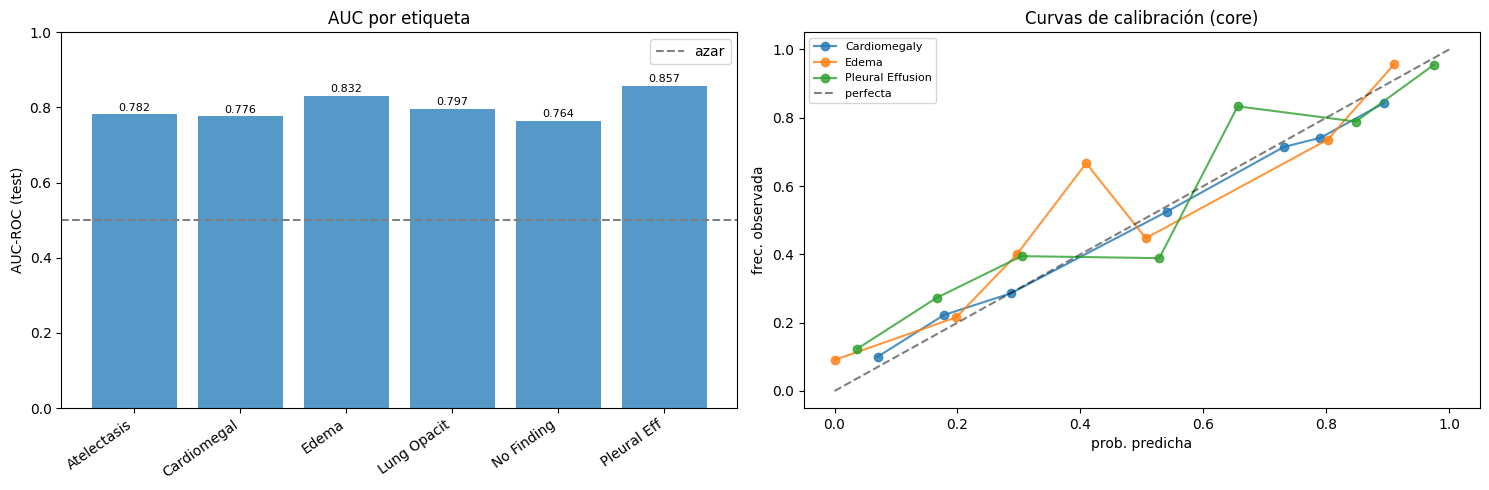

Figura guardada.


In [19]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ CELDA 17 · GRÁFICAS (AUC por etiqueta + curvas de calibración)             ║
# ╚══════════════════════════════════════════════════════════════════════════╝
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# AUC por etiqueta en test
ax = axes[0]
aucs = [test_metrics[l]["AUC"] for l in LABELS]
colors = ["#c0392b" if (np.isnan(a) or a < 0.55) else "#2980b9" for a in aucs]
ax.bar(range(N_LABELS), [0 if np.isnan(a) else a for a in aucs], color=colors, alpha=0.8)
ax.axhline(0.5, color="gray", ls="--", label="azar")
ax.set_xticks(range(N_LABELS)); ax.set_xticklabels([l[:11] for l in LABELS], rotation=35, ha="right")
ax.set_ylim(0, 1); ax.set_ylabel("AUC-ROC (test)"); ax.set_title("AUC por etiqueta")
ax.legend()
for i, a in enumerate(aucs):
    if not np.isnan(a): ax.text(i, a + 0.01, f"{a:.3f}", ha="center", fontsize=8)

# Calibración (reliability) de las patologías core
ax = axes[1]
for lbl in CORE_LABELS:
    j = LABELS.index(lbl); sel = m_test[:, j] == 1
    yt = y_test[sel, j]; yp = test_pred_cal[sel, j]
    bins = np.linspace(0, 1, 9); idx = np.digitize(yp, bins) - 1
    xs, ys = [], []
    for b in range(len(bins) - 1):
        mb = idx == b
        if mb.sum() > 5:
            xs.append(yp[mb].mean()); ys.append(yt[mb].mean())
    ax.plot(xs, ys, "o-", label=lbl, alpha=0.8)
ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="perfecta")
ax.set_xlabel("prob. predicha"); ax.set_ylabel("frec. observada")
ax.set_title("Curvas de calibración (core)"); ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "results_v5.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada.")


In [20]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ CELDA 18 · ANÁLISIS DE EQUIDAD POR SUBGRUPO (lo pide el EDA)                ║
# ╚══════════════════════════════════════════════════════════════════════════╝
# AUC macro (patologías) desagregado por género, vista, raza y tipo de ingreso.

dft = df_test.reset_index(drop=True)
for col, label in [("gender", "GÉNERO"), ("cxr_view", "VISTA"),
                   ("race", "RAZA"), ("admission_type", "INGRESO")]:
    if col not in dft.columns:
        continue
    print(f"\n-- AUC macro (patologías) por {label} --")
    for v in sorted(dft[col].dropna().unique(), key=str):
        idx = dft.index[dft[col] == v].to_numpy()
        if len(idx) < 15:
            print(f"   {str(v):22s} n={len(idx):4d}  (muestra insuficiente)")
            continue
        mm = multilabel_metrics(test_pred_cal[idx], y_test[idx], m_test[idx])
        print(f"   {str(v):22s} n={len(idx):4d}  macroAUC_path={mm['macro_AUC_path']:.4f}")
print("\nAnálisis de equidad completado.")



-- AUC macro (patologías) por GÉNERO --
   0                      n= 184  macroAUC_path=0.8310
   1                      n= 280  macroAUC_path=0.7938

-- AUC macro (patologías) por VISTA --
   AP                     n= 388  macroAUC_path=0.7821
   PA                     n=  76  macroAUC_path=0.8454

-- AUC macro (patologías) por RAZA --
   ASIAN                  n=  15  macroAUC_path=0.9287
   BLACK                  n=  58  macroAUC_path=0.7615
   HISPANIC_LATINO        n=  21  macroAUC_path=0.7183
   OTHER_KNOWN            n=   3  (muestra insuficiente)
   UNKNOWN                n=  52  macroAUC_path=0.8728
   WHITE                  n= 315  macroAUC_path=0.8013

-- AUC macro (patologías) por INGRESO --
   EMERGENCY              n= 322  macroAUC_path=0.8079
   OBSERVATION            n=  66  macroAUC_path=0.8301
   SCHEDULED              n=  34  macroAUC_path=0.7043
   URGENT                 n=  42  macroAUC_path=0.7957

Análisis de equidad completado.


---
## ✅ Resumen de lo que implementa esta v5

**Correcciones de raíz (lo que mataba el AUC en v3/v4):**
- **A · Preprocesado alineado**: 1 canal, min-max por imagen → **[−1024, 1024]**, **224×224** — el dominio que el backbone realmente espera.
- **B · Backbone correcto**: **DenseNet121 `densenet121-res224-all`** (CheXNet), pequeño, nativo 224 y entrenado en estas mismas patologías.
- **C · Negativos derivados por exclusividad** (`No Finding` ↔ patologías): Atelectasis y Lung Opacity dejan de ser indiscriminables y *No Finding* se vuelve entrenable. **Solo rellena NaN; nunca pisa valores explícitos ni inciertos; el masking sigue intacto.**

**Calidad y rigor:**
- `pos_weight` **dinámico** por fold sobre objetivos efectivos · `WeightedRandomSampler` por rareza · pérdida BCE/**focal** enmascarada.
- **Optuna (TPE)** para hiperparámetros · **K-fold** para estimación honesta de varianza.
- **Calibración isotónica** ajustada en val.
- Métricas separadas: **macro core (3)**, **macro patologías (5)**, **No Finding aparte**, y per-etiqueta con N⁺/N⁻.
- **Análisis de equidad** por subgrupos.

**Listo para fusión tardía (stacking):**
- `cxr_pred_oof_train.csv` (probabilidades **out-of-fold**, sin fuga) → para entrenar el meta-modelo.
- `cxr_pred_val.csv`, `cxr_pred_test.csv` (crudas y **calibradas**) → para validar y testear el ensemble.

**Coste**: una pasada de embeddings (~30–45 min, cacheada) + minutos de cabeza/Optuna/K-fold ≈ **1 h** la primera vez, segundos después.

## 🔧 Palancas que puedes tocar
- `DERIVE_NEGATIVES_FROM_EXCLUSIVITY` → comparar con/sin la regla de exclusividad.
- `OPTUNA_TRIALS`, `K_FOLDS`, `FINAL_EPOCHS` → más presupuesto = algo más de AUC y mejor estimación.
- `BACKBONE_WEIGHTS` → probar otros pesos xrv (p.ej. `densenet121-res224-mimic_ch`).

## 📌 Próximos pasos
1. Verificar que `macro_AUC_path` supera claramente 0.50 (debería, por las correcciones A+B).
2. Integrar `cxr_pred_*.csv` con las features de XGBoost (tabular) y ResNet1D (ECG) en el meta-modelo.
3. Documentar en la memoria la regla de negativos derivados como decisión de modelado justificada clínicamente.
